In [6]:
import os
import numpy as np
import pandas as pd
import cv2 as cv
from pathlib import Path
import warnings
from skimage.feature import hog
import tqdm
from PIL import Image
import pickle

warnings.filterwarnings("ignore")
pd.options.display.max_columns = None

In [15]:
# all_images = []
# #labels = []

# def load_image(ids,path=image_folder):
#     img = cv.imread(image_folder+ids+'.jpg',cv.IMREAD_GRAYSCALE) #load at gray scale
#     #img = cv.cvtColor(img, cv.COLOR_BGR2GRAY) #convert to gray scale
#     return img,ids

# for ids in tqdm(list(styles.id)[:20000]):
#     img,ids = load_image(str(ids))
#     if img is not None:
#         all_images.append([img,int(ids)])
#     #labels.append(ids)
# len(all_images)

video_folder = "/media/osero/SamsungSSD/CMPE_SSD/frame-hand_left-c256_TOY"
labels = [] 
all_images = []
process_count = 0
for label_folder in os.listdir(video_folder):
    process_count += 1
    full_label_folder = os.path.join(video_folder, label_folder)
    label = int(label_folder)
    print("process_count: ", process_count, ' , label: ', label)
    for sample_folder in os.listdir(full_label_folder):
        full_sample_folder = os.path.join(full_label_folder, sample_folder)
        image_list = []
        for image_file in os.listdir(full_sample_folder):
            full_image_file = os.path.join(full_sample_folder, image_file)
            image = cv.imread(full_image_file, cv.IMREAD_GRAYSCALE)
            image_list.append(image)
        all_images.append(image_list)
        labels.append(label)

process_count:  1  , label:  18
process_count:  2  , label:  19
process_count:  3  , label:  8
process_count:  4  , label:  10
process_count:  5  , label:  15
process_count:  6  , label:  17
process_count:  7  , label:  12
process_count:  8  , label:  20
process_count:  9  , label:  2
process_count:  10  , label:  6
process_count:  11  , label:  3
process_count:  12  , label:  7
process_count:  13  , label:  11
process_count:  14  , label:  9
process_count:  15  , label:  14
process_count:  16  , label:  5
process_count:  17  , label:  13
process_count:  18  , label:  4
process_count:  19  , label:  1
process_count:  20  , label:  16


In [7]:
# np.array(all_images[0])

In [19]:
def resize_images(img_list):
    for img in img_list:
        aaa = cv.resize(img, (60, 80),interpolation =cv.INTER_LINEAR) 
        ccc = 4
    return [cv.resize(img, (60, 80),interpolation =cv.INTER_LINEAR) for img in img_list]

all_images_resized = [resize_images(x) for x in all_images]
len(all_images_resized)

KeyboardInterrupt: 

In [36]:
df_labels = pd.DataFrame(all_images_resized,columns=['image','id'])

target = 'masterCategory'
categories = ['Apparel', 'Accessories', 'Footwear', 'Personal Care', 'Free Items']
df_train = styles[styles[target].isin(categories)][['id',target]]

df_labels = pd.merge(df_labels,df_train,how='left',on=['id'])
df_labels = df_labels.fillna('Others')
df_labels['class'] = pd.factorize(df_labels[target])[0]
print("Data Shape: ", str(df_labels.shape))
print(df_labels[target].value_counts())

Data Shape:  (19998, 4)
Apparel          9675
Accessories      5079
Footwear         4121
Personal Care    1072
Free Items         41
Others             10
Name: masterCategory, dtype: int64


In [37]:
mapper = df_labels[['class',target]].drop_duplicates()

Total Keypoints with nonmaxSuppression: 1


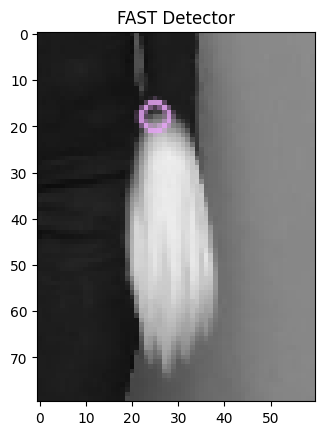

Total Keypoints with nonmaxSuppression: 30


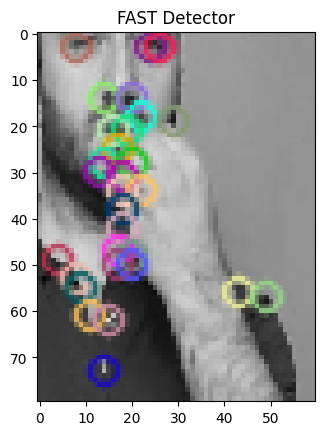

Total Keypoints with nonmaxSuppression: 32


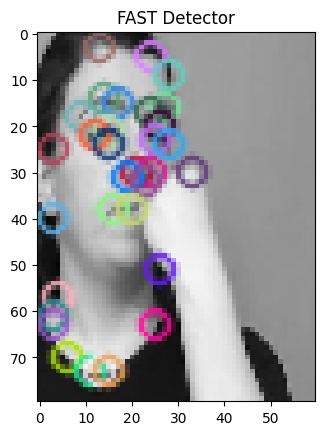

Total Keypoints with nonmaxSuppression: 1


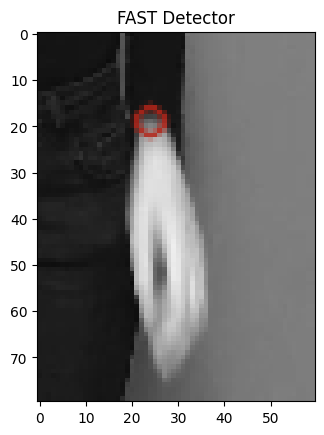

Total Keypoints with nonmaxSuppression: 15


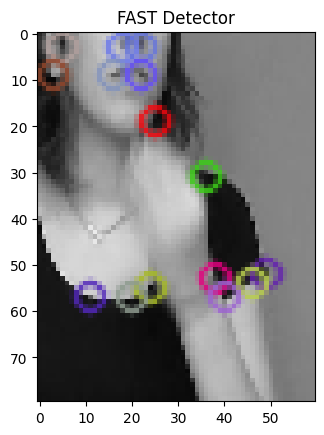

Total Keypoints with nonmaxSuppression: 34


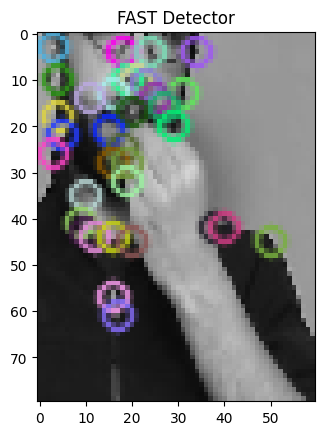

Total Keypoints with nonmaxSuppression: 9


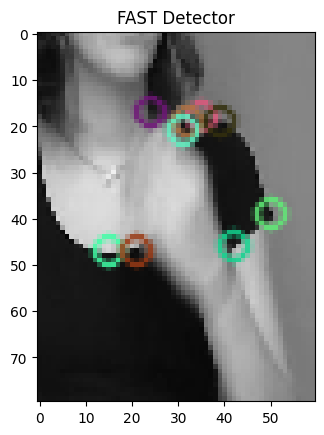

Total Keypoints with nonmaxSuppression: 32


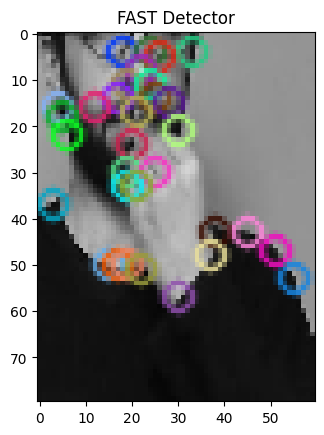

Total Keypoints with nonmaxSuppression: 42


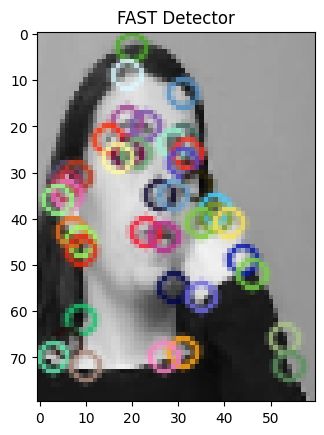

Total Keypoints with nonmaxSuppression: 23


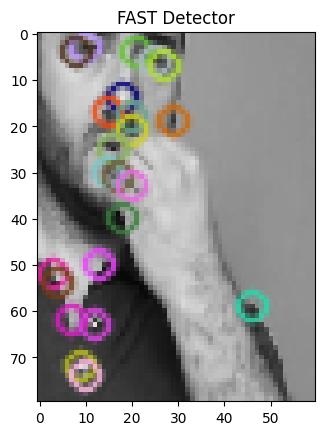

Total Keypoints with nonmaxSuppression: 1


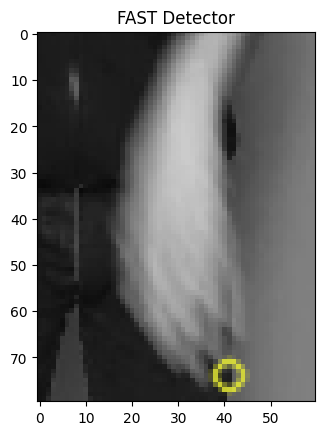

Total Keypoints with nonmaxSuppression: 29


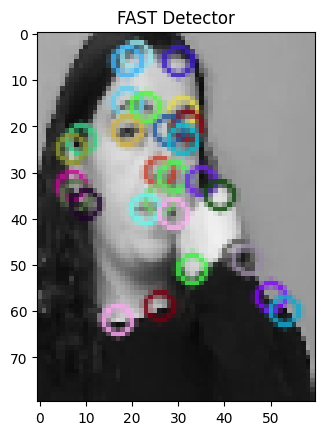

Total Keypoints with nonmaxSuppression: 20


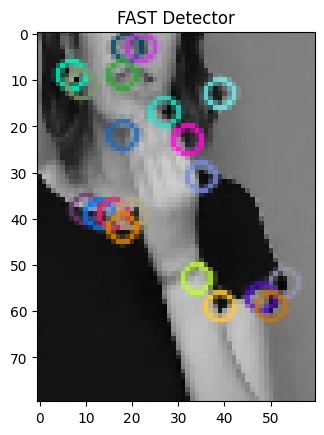

Total Keypoints with nonmaxSuppression: 19


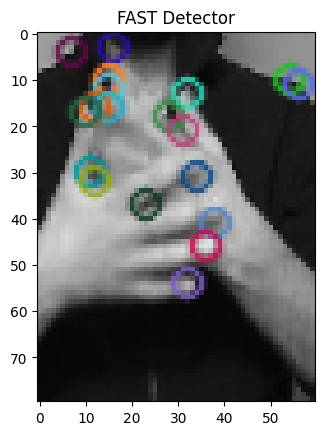

Total Keypoints with nonmaxSuppression: 17


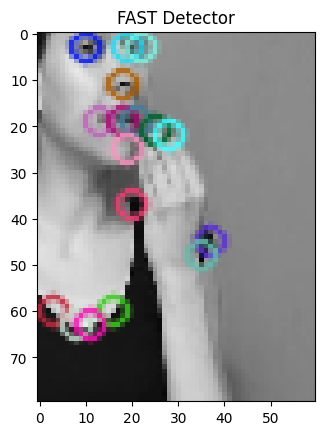

Total Keypoints with nonmaxSuppression: 8


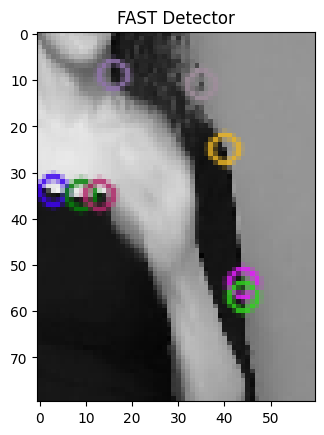

Total Keypoints with nonmaxSuppression: 33


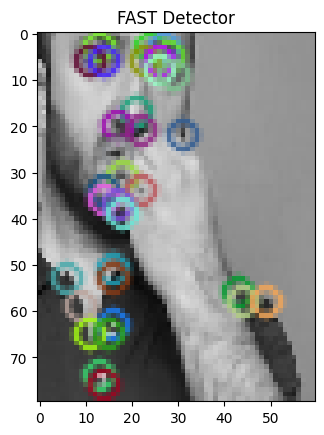

Total Keypoints with nonmaxSuppression: 30


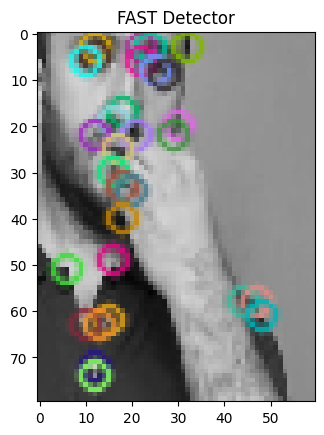

Total Keypoints with nonmaxSuppression: 5


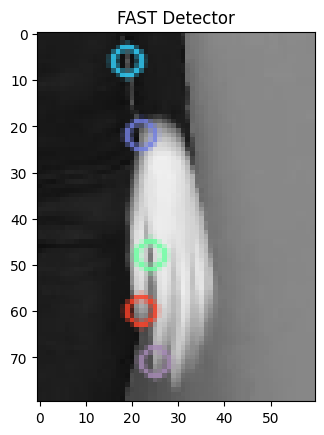

Total Keypoints with nonmaxSuppression: 34


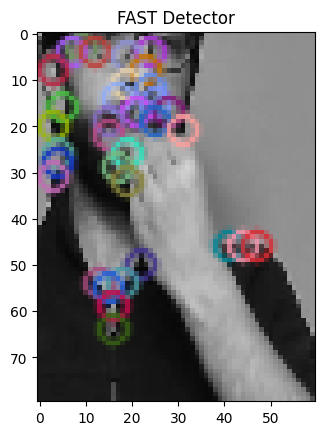

In [20]:
from matplotlib import pyplot as plt


for image in all_images_resized[:20]:
    image = image[0]
    # print(image.shape)
    plt.imshow(image)
    fast = cv.FastFeatureDetector_create(50)
    kp = fast.detect(image,None)
    img2 = cv.drawKeypoints(image, kp, None, color=(255,0,0))
    # Print all default params
    #print( "Threshold: {}".format(fast.getThreshold()) )
    #print( "neighborhood: {}".format(fast.getType()) )
    print( "Total Keypoints with nonmaxSuppression: {}".format(len(kp)))
    fast_image=cv.drawKeypoints(image,kp,image)
    plt.imshow(fast_image);plt.title('FAST Detector')
    plt.show()

In [21]:
train_images = np.stack(df_labels.image.values,axis=0)
n_samples = len(train_images)
data_images = train_images.reshape((n_samples, -1))

NameError: name 'df_labels' is not defined

In [40]:
ppcr = 8
ppcc = 8
hog_images = []
hog_features = []
for image in tqdm(train_images):
    blur = cv.GaussianBlur(image,(5,5),0)
    fd,hog_image = hog(blur, orientations=8, pixels_per_cell=(ppcr,ppcc),cells_per_block=(2,2),block_norm= 'L2',visualize=True)
    hog_images.append(hog_image)
    hog_features.append(fd)

hog_features = np.array(hog_features)

hog_features.shape

100%|████████████████████████████████████████████████████████████████████████████| 19998/19998 [04:45<00:00, 70.06it/s]


(19998, 1728)

In [41]:
edges = [cv.Canny(image,50,150,apertureSize = 3) for image in train_images]
edges = np.array(edges)
n_samples_edges = len(edges)
edge_images = edges.reshape((n_samples, -1))
edge_images.shape

(19998, 4800)

In [42]:
train_images.shape, hog_features.shape, edge_images.shape

((19998, 80, 60), (19998, 1728), (19998, 4800))

In [43]:
edge_hog = np.hstack([hog_features,edge_images])
edge_hog.shape

(19998, 6528)

In [44]:
histr = [cv.calcHist([img],[0],None,[256],[0,256]) for img in train_images]
histr = np.array(histr)
n_samples_histr = len(histr)
image_hist = histr.reshape((n_samples_histr, -1))
image_hist.shape

(19998, 256)

In [45]:
edge_hog = np.hstack([hog_features,edge_images,image_hist])
edge_hog.shape

(19998, 6784)

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(hog_features,df_labels['class'],test_size=0.2,stratify=df_labels['class'])
print('Training data and target sizes: \n{}, {}'.format(X_train.shape,y_train.shape))
print('Test data and target sizes: \n{}, {}'.format(X_test.shape,y_test.shape))

Training data and target sizes: 
(15998, 1728), (15998,)
Test data and target sizes: 
(4000, 1728), (4000,)


In [47]:
y_train.value_counts(),y_test.value_counts()

(0    7740
 1    4063
 2    3297
 3     857
 4      33
 5       8
 Name: class, dtype: int64,
 0    1935
 1    1016
 2     824
 3     215
 4       8
 5       2
 Name: class, dtype: int64)

In [48]:
from sklearn import datasets, svm, metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
# # Create a classifier: a support vector classifier
# classifier = svm.SVC(gamma=0.001)
# #fit to the trainin data
# classifier.fit(X_train,y_train)

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

test_accuracy = []
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

classifier = KNeighborsClassifier(n_neighbors=3,algorithm='brute')
classifier.fit(X_scaled, y_train)
test_accuracy = classifier.score(scaler.transform(X_test), y_test)
print(test_accuracy)

# #FOR TUNING
# print(search_params)
# for p in tqdm(search_params):
#     #classifier = svm.SVC(gamma=p)
#     classifier = RandomForestClassifier(max_depth=8,n_estimators=600)

#     classifier.fit(X_scaled, y_train)
#     test_accuracy.append([p,classifier.score(scaler.transform(X_test), y_test)])

# df_accuracy = pd.DataFrame(test_accuracy,columns =['gamma','accuracy'])
# df_accuracy.index = df_accuracy.gamma
# df_accuracy[['accuracy']].plot()
# plt.show()

0.97775


In [50]:
##PCA
from sklearn.decomposition import PCA
# pca = PCA(.90)
# principalComponents = pca.fit_transform(X = X_scaled)

In [51]:
mapper= mapper.reset_index(drop=True)

In [62]:
y_pred = classifier.predict(scaler.transform(X_test))

df_result = pd.DataFrame(y_test)
df_result['id'] = df_result.index
df_result = df_result.rename(columns={'class':'actual'})
df_result['predicted'] = y_pred
df_result = df_result.reset_index(drop=True)
df_result = pd.merge(df_result,mapper,left_on='predicted',right_on = 'class',how='inner')
df_result = df_result.drop(columns=['class'],axis=1)
df_result = df_result.rename(columns={'gender':'predicted_category'})

df_result = pd.merge(df_result,mapper,left_on='actual',right_on = 'class',how='inner')
df_result = df_result.drop(columns=['class'],axis=1)
df_result.shape

(4000, 5)

In [63]:
#some references for debugging
kd = df_result[df_result.actual!=df_result.predicted]
print(kd.shape)
kd.head()

(89, 5)


,actual,id,predicted,masterCategory_x,masterCategory_y
1917,0,17273,1,Accessories,Apparel
1918,0,4139,1,Accessories,Apparel
1919,0,14127,1,Accessories,Apparel
1920,0,8968,1,Accessories,Apparel
1921,0,4008,1,Accessories,Apparel


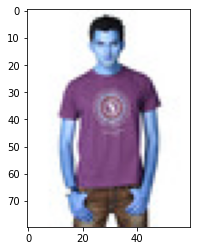

In [64]:
# image_id = styles[styles.index==2663]['id'].reset_index(drop=True)
# k = str(image_id)
# print(k)
#print(image_folder+str(image_id)+'.jpg')

#debug image with id
img = cv.imread(image_folder+str(7347)+'.jpg')
img.shape
plt.imshow(img)

In [99]:
list_of_categories = categories +['Others']

print("Classification Report: \n Target: %s \n Labels: %s \n Classifier: %s:\n%s\n"
      % (target,list_of_categories,classifier, metrics.classification_report(y_test, y_pred)))

df_report = pd.DataFrame(metrics.confusion_matrix(y_test, y_pred),columns = list_of_categories )
df_report.index = [list_of_categories]
df_report

Classification Report: 
 Target: masterCategory 
 Labels: ['Apparel', 'Accessories', 'Footwear', 'Personal Care', 'Free Items', 'Others'] 
 Classifier: KNeighborsClassifier(algorithm='brute', n_neighbors=3):
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1935
           1       0.97      0.96      0.96      1016
           2       0.99      1.00      1.00       824
           3       0.92      0.93      0.92       215
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00         2

    accuracy                           0.98      4000
   macro avg       0.64      0.65      0.64      4000
weighted avg       0.98      0.98      0.98      4000




,Apparel,Accessories,Footwear,Personal Care,Free Items,Others
Apparel,1917,9,1,8,0,0
Accessories,30,972,4,10,0,0
Footwear,1,1,822,0,0,0
Personal Care,1,12,0,200,0,2
Free Items,2,6,0,0,0,0
Others,2,0,0,0,0,0


In [72]:
categories

['Apparel', 'Accessories', 'Footwear', 'Personal Care', 'Free Items']

In [76]:
df_report

,Apparel,Accessories,Footwear,Personal Care,Free Items,others
Apparel,1917,9,1,8,0,0
Accessories,30,972,4,10,0,0
Footwear,1,1,822,0,0,0
Personal Care,1,12,0,200,0,2
Free Items,2,6,0,0,0,0
others,2,0,0,0,0,0


In [121]:

#test image with id
test_data_location = root+'/test/'

img = cv.imread(test_data_location+'2093.jpg',cv.IMREAD_GRAYSCALE) #load at gray scale
image = cv.resize(img, (60, 80),interpolation =cv.INTER_LINEAR)

ppcr = 8
ppcc = 8
hog_images_test = []
hog_features_test = []

blur = cv.GaussianBlur(image,(5,5),0)
fd_test,hog_img = hog(blur, orientations=8, pixels_per_cell=(ppcr,ppcc),cells_per_block=(2,2),block_norm= 'L2',visualize=True)
hog_images_test.append(hog_img)
hog_features_test.append(fd)

hog_features_test = np.array(hog_features_test)
y_pred_user = classifier.predict(scaler.transform(hog_features_test))
#print(plt.imshow(hog_images_test))
print(y_pred_user)
print("Predicted MaterCategory: ", mapper[mapper['class']==int(y_pred_user)]['masterCategory'])

[0]
Predicted MaterCategory:  0    Apparel
Name: masterCategory, dtype: object


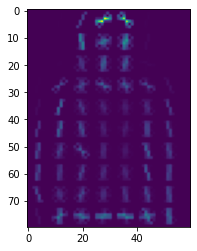

In [122]:
plt.imshow(hog_img)
plt.show()

In [123]:
hog_features.shape

(19998, 1728)

In [133]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

scaler_global = MinMaxScaler()
final_features_scaled = scaler_global.fit_transform(hog_features)
    
neighbors = NearestNeighbors(n_neighbors=20, algorithm='brute')
neighbors.fit(final_features_scaled)

distance,potential = neighbors.kneighbors(scaler_global.transform(hog_features_test))
print("Potential Neighbors Found!")
neighbors = []
for i in potential[0]:
    neighbors.append(i)

recommendation_list = list(df_labels.iloc[neighbors]['id'])
recommendation_list

Potential Neighbors Found!


[7572,
 7567,
 7558,
 7569,
 9557,
 2617,
 22597,
 5434,
 6568,
 9551,
 14132,
 14006,
 15604,
 30618,
 11269,
 6528,
 7520,
 28536,
 9535,
 7580]